In [9]:
import mlflow
import mlflow.sklearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
mlflow.set_experiment("Potabilidad_Arbol_Experimento")

<Experiment: artifact_location='/home/ygalindo/proyectoDesarrollo/WaterPotability/notebooks/mlruns/1', creation_time=1771704407346, experiment_id='1', last_update_time=1771704407346, lifecycle_stage='active', name='Potabilidad_Arbol_Experimento', tags={}, workspace='default'>

In [11]:
data = pd.read_csv("../data/Datos_Etapa-2.csv", sep=",", na_values=["?"])

data["Potabilidad"] = data["Potabilidad"].map({"NO": 0, "SI": 1})

X = data.drop("Potabilidad", axis=1)
y = data["Potabilidad"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9
)

In [13]:
numeric_features = ['pH', 'Sulfatos', 'Trihalometanos']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=77
    ))
])

In [14]:
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4,6,8,10,12],
    'classifier__min_samples_split': [3,4,5]
}

kfold = KFold(n_splits=10, shuffle=True, random_state=77)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=kfold,
    n_jobs=-1
)

2026/02/21 15:14:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/21 15:14:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Modelo_Potabilidad' already exists. Creating a new version of this model...
Created version '2' of model 'Modelo_Potabilidad'.


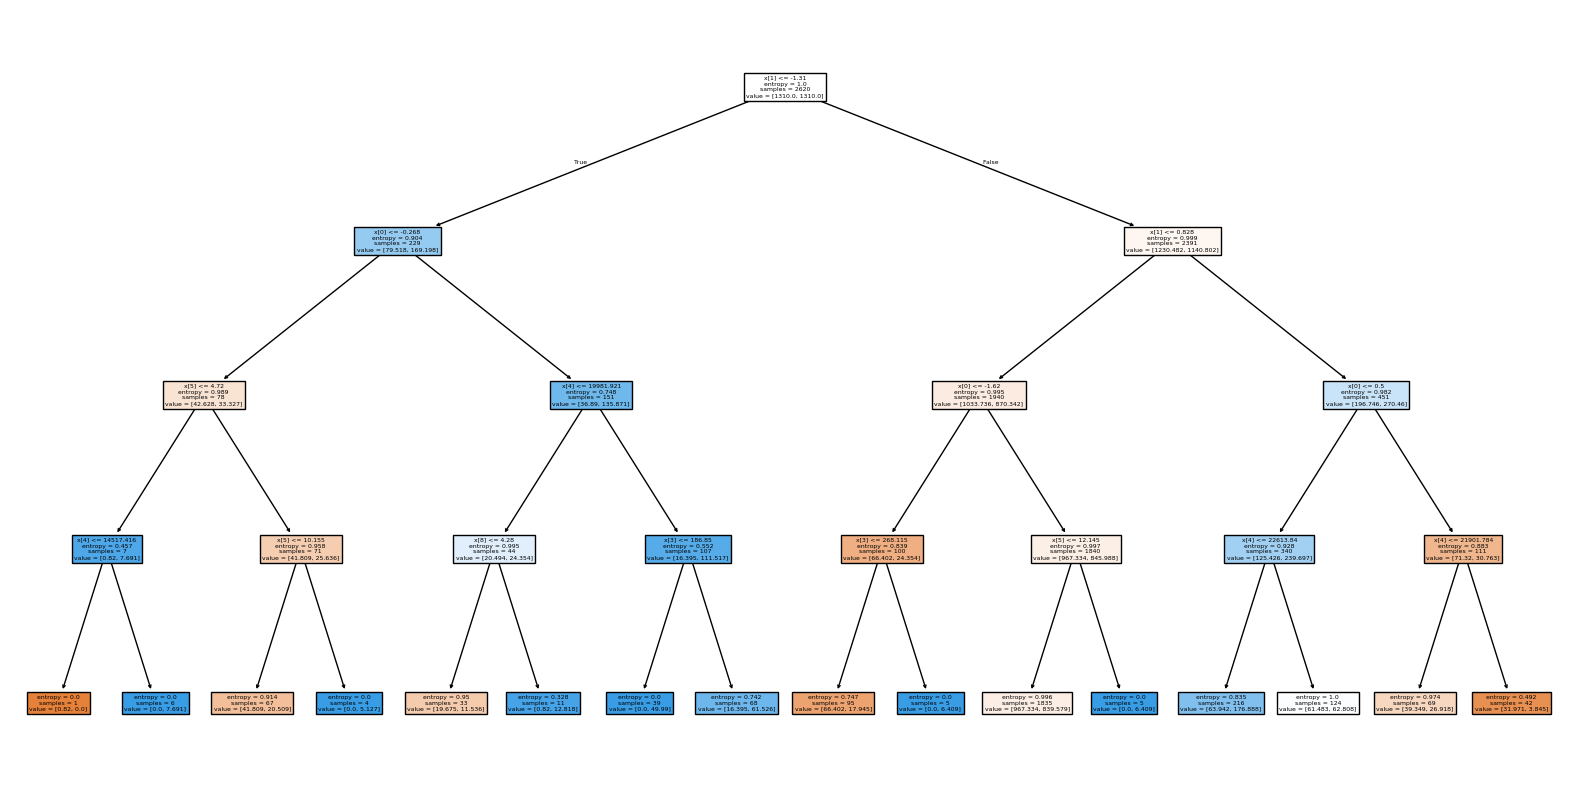

In [15]:
with mlflow.start_run():

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_params(grid.best_params_)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)

    # 👇 REGISTRAR MODELO AQUÍ
    mlflow.sklearn.log_model(
        best_model,
        "modelo_potabilidad",
        registered_model_name="Modelo_Potabilidad"
    )

    plt.figure(figsize=(20,10))
    plot_tree(best_model.named_steps['classifier'], filled=True)
    plt.savefig("arbol.png")
    mlflow.log_artifact("arbol.png")